In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import shap
%matplotlib inline
sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isna().sum())
print("\nChurn distribution:")
print(df['churn'].value_counts(normalize=True))

Shape: (10000, 12)

Columns:
['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

Missing values:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Churn distribution:
churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [5]:
df = df.drop(columns=['customer_id'])

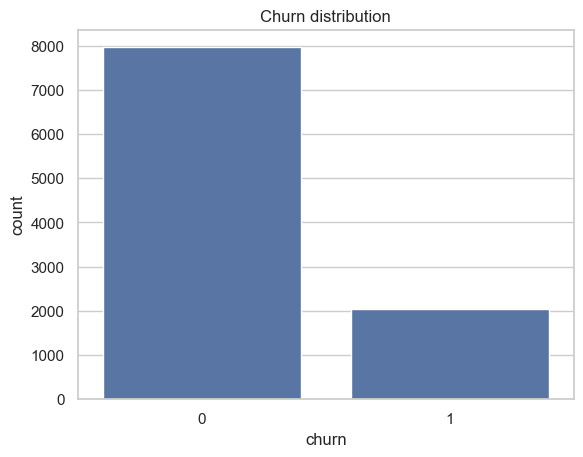

In [6]:
plt.figure()
sns.countplot(data=df, x="churn")
plt.title("Churn distribution")
plt.savefig("fig_churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

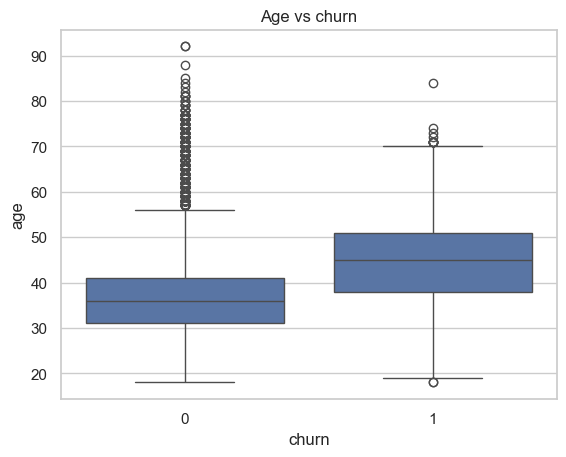

In [7]:
plt.figure()
sns.boxplot(data=df, x="churn", y="age")
plt.title("Age vs churn")
plt.savefig("fig_age_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

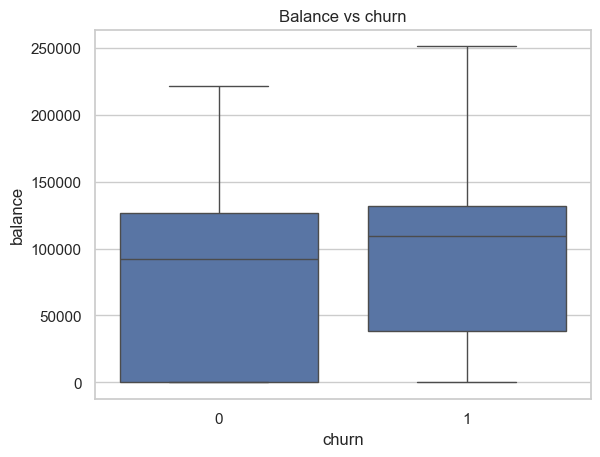

In [8]:
plt.show()
plt.figure()
sns.boxplot(data=df, x="churn", y="balance")
plt.title("Balance vs churn")
plt.savefig("fig_balance_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

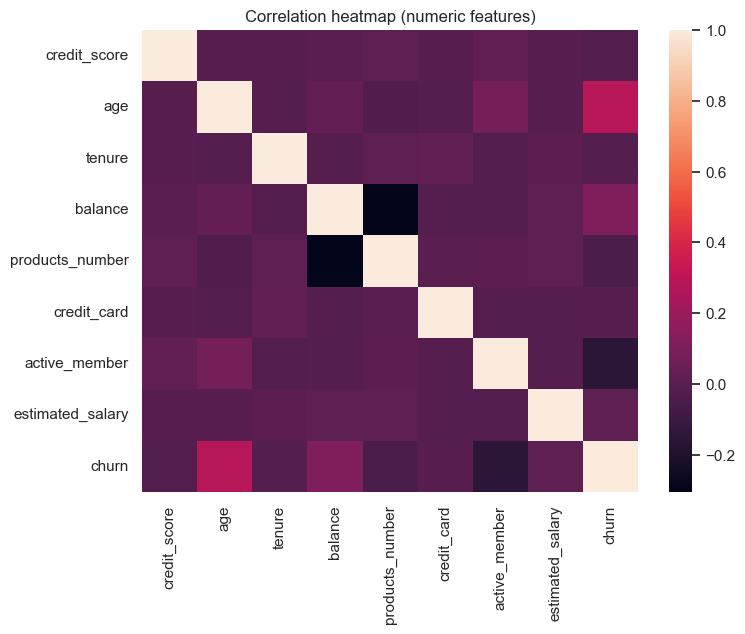

In [9]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=False)
plt.title("Correlation heatmap (numeric features)")
plt.savefig("fig_corr_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

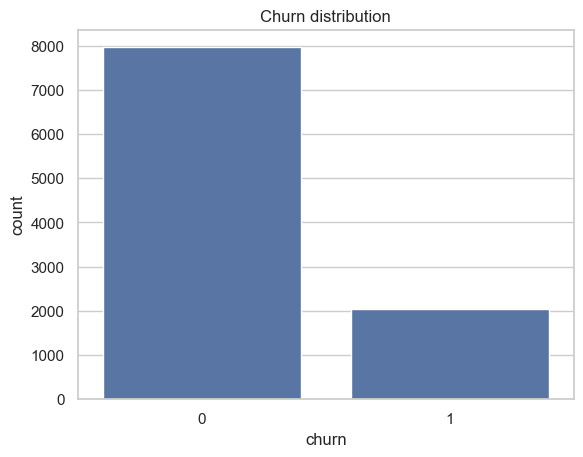

churn
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [10]:
plt.figure()
sns.countplot(data=df, x="churn")
plt.title("Churn distribution")
plt.savefig("fig_churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print(df["churn"].value_counts(normalize=True))

In [11]:
df.groupby("churn")[numeric_cols].mean()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
churn,,,,,,,,,
0,651.853196,37.408389,5.033279,72745.296779,1.544267,0.707146,0.554565,99738.391772,0.0
1,645.351497,44.837997,4.932744,91108.539337,1.475209,0.699067,0.360825,101465.677531,1.0


In [12]:
X = df.drop(columns=["churn"])
y = df["churn"]
categorical_cols = ["country", "gender"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)
log_reg_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])
log_reg_model.fit(X_train, y_train)
y_proba = log_reg_model.predict_proba(X_test)[:, 1]
y_pred = log_reg_model.predict(X_test)
print("LogReg ROC-AUC:", roc_auc_score(y_test, y_proba))
print("LogReg F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

LogReg ROC-AUC: 0.7747578086561138
LogReg F1: 0.2835820895522388
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [13]:
rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_pred = rf_model.predict(X_test)
results = pd.DataFrame([
    {"model": "LogisticRegression", "roc_auc": roc_auc_score(y_test, y_proba), "f1": f1_score(y_test, y_pred)},
    {"model": "RandomForest", "roc_auc": roc_auc_score(y_test, rf_proba), "f1": f1_score(y_test, rf_pred)},
])

results

,model,roc_auc,f1
0,LogisticRegression,0.774758,0.283582
1,RandomForest,0.849976,0.555901


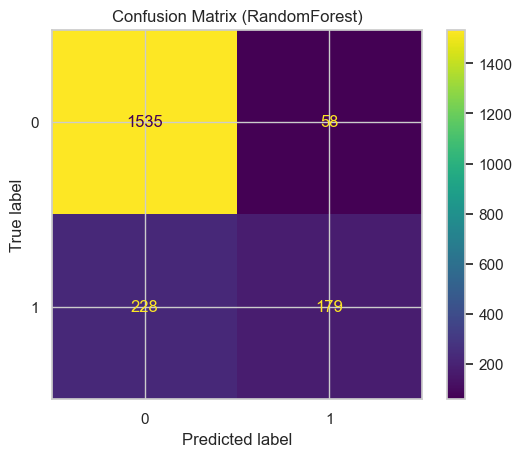

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (RandomForest)")
plt.savefig("fig_confusion_matrix_rf.png", dpi=300, bbox_inches="tight")
plt.show()

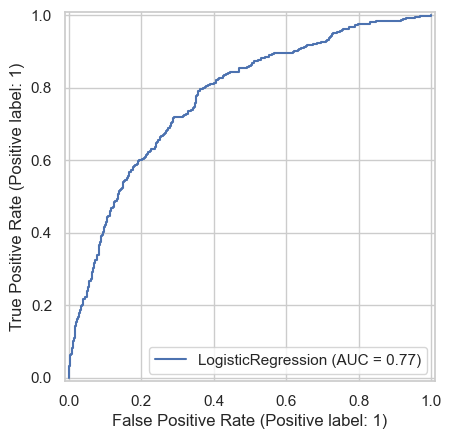

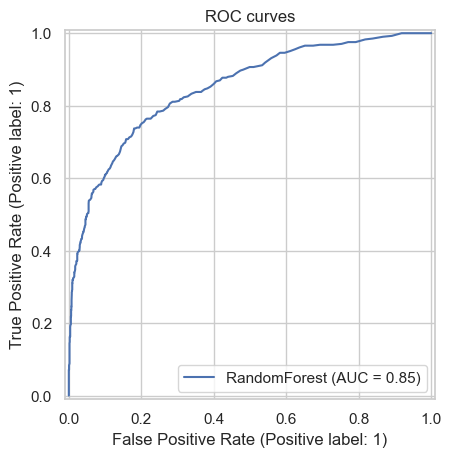

In [15]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_proba, name="LogisticRegression")
RocCurveDisplay.from_predictions(y_test, rf_proba, name="RandomForest")
plt.title("ROC curves")
plt.savefig("fig_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

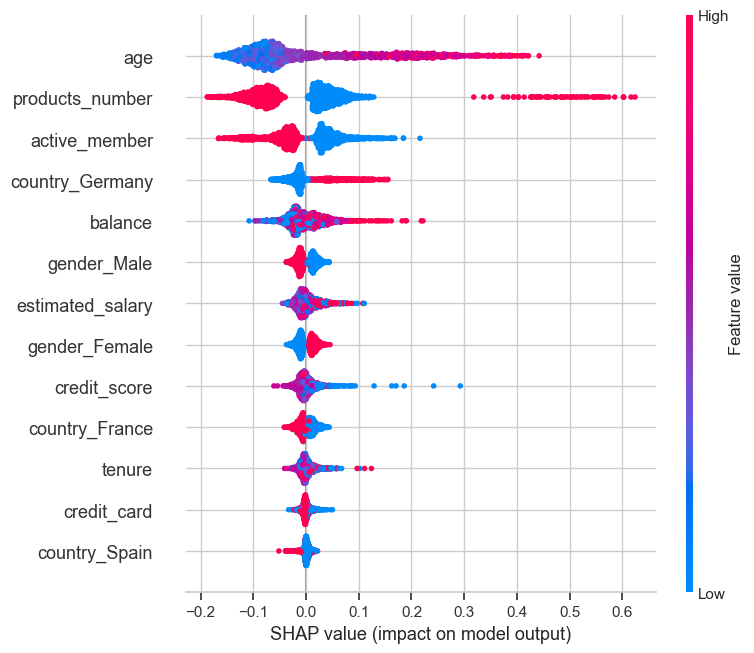

In [16]:
X_test_transformed = rf_model.named_steps["preprocess"].transform(X_test)
preprocess_fitted = rf_model.named_steps["preprocess"]
ohe = preprocess_fitted.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(["country", "gender"])
feature_names = numeric_cols + cat_feature_names.tolist()
explainer = shap.TreeExplainer(rf_model.named_steps["model"])
shap_values = explainer.shap_values(X_test_transformed)
if isinstance(shap_values, list):
    shap_class1 = shap_values[1]
else:
    shap_class1 = shap_values[:, :, 1]
shap.summary_plot(
    shap_class1,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)
plt.savefig("fig_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
import os
os.listdir()

['Cod.ipynb',
 'fig_corr_heatmap.png',
 'fig_age_vs_churn.png',
 'fig_shap_summary.png',
 'fig_confusion_matrix_rf.png',
 'Cod\xa0— копия.ipynb',
 'fig_mlp_shap_bar.png',
 'fig_roc_curves.png',
 'fig_final_calibration_comparison.png',
 'fig_final_pr_comparison.png',
 'fig_churn_distribution.png',
 'fig_confusion_matrix_rf_threshold_040.png',
 'fig_balance_vs_churn.png',
 'fig_confusion_matrix_tuned_rf_threshold_045.png',
 'fig_final_roc_comparison.png',
 'Cod\xa0— копия 2.ipynb',
 'fig_local_waterfall.png',
 'Bank Customer Churn Prediction.csv',
 'main.py',
 '.idea']

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scoring = {
    "roc_auc": "roc_auc",
    "f1": make_scorer(f1_score)
}

In [19]:
log_reg_cv = cross_validate(
    log_reg_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
rf_cv = cross_validate(
    rf_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [20]:
cv_results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "roc_auc_mean": log_reg_cv["test_roc_auc"].mean(),
        "roc_auc_std": log_reg_cv["test_roc_auc"].std(),
        "f1_mean": log_reg_cv["test_f1"].mean(),
        "f1_std": log_reg_cv["test_f1"].std()
    },
    {
        "model": "Random Forest",
        "roc_auc_mean": rf_cv["test_roc_auc"].mean(),
        "roc_auc_std": rf_cv["test_roc_auc"].std(),
        "f1_mean": rf_cv["test_f1"].mean(),
        "f1_std": rf_cv["test_f1"].std()
    }
])
cv_results

,model,roc_auc_mean,roc_auc_std,f1_mean,f1_std
0,Logistic Regression,0.766089,0.014621,0.312936,0.017138
1,Random Forest,0.852771,0.003569,0.579317,0.020684


In [21]:
log_reg_balanced_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

rf_balanced_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

In [22]:
log_reg_balanced_cv = cross_validate(
    log_reg_balanced_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
rf_balanced_cv = cross_validate(
    rf_balanced_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [24]:
cv_results_balanced = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "roc_auc_mean": log_reg_cv["test_roc_auc"].mean(),
        "roc_auc_std": log_reg_cv["test_roc_auc"].std(),
        "f1_mean": log_reg_cv["test_f1"].mean(),
        "f1_std": log_reg_cv["test_f1"].std()
    },
    {
        "model": "Logistic Regression balanced",
        "roc_auc_mean": log_reg_balanced_cv["test_roc_auc"].mean(),
        "roc_auc_std": log_reg_balanced_cv["test_roc_auc"].std(),
        "f1_mean": log_reg_balanced_cv["test_f1"].mean(),
        "f1_std": log_reg_balanced_cv["test_f1"].std()
    },
    {
        "model": "Random Forest",
        "roc_auc_mean": rf_cv["test_roc_auc"].mean(),
        "roc_auc_std": rf_cv["test_roc_auc"].std(),
        "f1_mean": rf_cv["test_f1"].mean(),
        "f1_std": rf_cv["test_f1"].std()
    },
    {
        "model": "Random Forest balanced",
        "roc_auc_mean": rf_balanced_cv["test_roc_auc"].mean(),
        "roc_auc_std": rf_balanced_cv["test_roc_auc"].std(),
        "f1_mean": rf_balanced_cv["test_f1"].mean(),
        "f1_std": rf_balanced_cv["test_f1"].std()
    }
])
cv_results_balanced

,model,roc_auc_mean,roc_auc_std,f1_mean,f1_std
0,Logistic Regression,0.766089,0.014621,0.312936,0.017138
1,Logistic Regression balanced,0.769309,0.014497,0.493397,0.015991
2,Random Forest,0.852771,0.003569,0.579317,0.020684
3,Random Forest balanced,0.852788,0.004806,0.561104,0.025274


In [25]:
scoring_extended = {
    "roc_auc": "roc_auc",
    "f1": make_scorer(f1_score),
    "precision": "precision",
    "recall": "recall"
}

In [26]:
models_for_cv = {
    "Logistic Regression": log_reg_model,
    "Logistic Regression balanced": log_reg_balanced_model,
    "Random Forest": rf_model,
    "Random Forest balanced": rf_balanced_model
}
extended_results = []
for model_name, model in models_for_cv.items():
    cv_result = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring_extended,
        n_jobs=-1
    )
    extended_results.append({
        "model": model_name,
        "roc_auc_mean": cv_result["test_roc_auc"].mean(),
        "f1_mean": cv_result["test_f1"].mean(),
        "precision_mean": cv_result["test_precision"].mean(),
        "recall_mean": cv_result["test_recall"].mean()
    })
extended_cv_results = pd.DataFrame(extended_results)
extended_cv_results

,model,roc_auc_mean,f1_mean,precision_mean,recall_mean
0,Logistic Regression,0.766089,0.312936,0.600991,0.211595
1,Logistic Regression balanced,0.769309,0.493397,0.383829,0.691205
2,Random Forest,0.852771,0.579317,0.764467,0.466886
3,Random Forest balanced,0.852788,0.561104,0.770415,0.441857


In [27]:
rf_model.fit(X_train, y_train)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score
thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []
for threshold in thresholds:
    y_pred_threshold = (rf_proba >= threshold).astype(int)
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold),
        "recall": recall_score(y_test, y_pred_threshold),
        "f1": f1_score(y_test, y_pred_threshold)
    })

threshold_results = pd.DataFrame(threshold_results)
threshold_results

,threshold,precision,recall,f1
0,0.10,0.323322,0.899263,0.475634
1,0.15,0.378889,0.837838,0.521806
2,0.20,0.450565,0.783784,0.572197
3,0.25,0.511073,0.737101,0.603622
4,0.30,0.564211,0.658477,0.607710
5,0.35,0.608911,0.604423,0.606658
6,0.40,0.679525,0.562654,0.615591
7,0.45,0.717857,0.493857,0.585153
8,0.50,0.755274,0.439803,0.555901
9,0.55,0.786408,0.398034,0.528548


In [29]:
best_threshold_row = threshold_results.sort_values(
    "f1",
    ascending=False
).iloc[0]
best_threshold_row

threshold    0.400000
precision    0.679525
recall       0.562654
f1           0.615591
Name: 6, dtype: float64

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
rf_pred_050 = (rf_proba >= 0.50).astype(int)
rf_pred_040 = (rf_proba >= 0.40).astype(int)
cm_050 = confusion_matrix(y_test, rf_pred_050)
cm_040 = confusion_matrix(y_test, rf_pred_040)
print("Confusion matrix with threshold 0.50:")
print(cm_050)
print("\nConfusion matrix with threshold 0.40:")
print(cm_040)

Confusion matrix with threshold 0.50:
[[1534   59]
 [ 227  180]]

Confusion matrix with threshold 0.40:
[[1485  108]
 [ 176  231]]


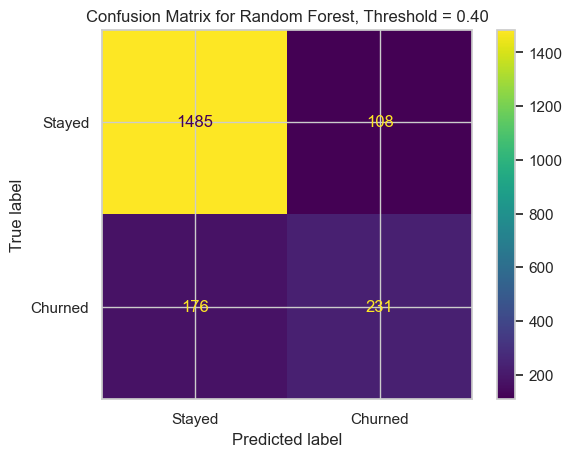

In [31]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_040,
    display_labels=["Stayed", "Churned"]
)

disp.plot()
plt.title("Confusion Matrix for Random Forest, Threshold = 0.40")
plt.savefig("fig_confusion_matrix_rf_threshold_040.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
from sklearn.model_selection import RandomizedSearchCV
rf_for_tuning = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])
param_distributions = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4, 6],
    "model__class_weight": [None, "balanced"]
}

In [34]:
rf_search = RandomizedSearchCV(
    estimator=rf_for_tuning,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': [None, 'balanced'], 'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation stra

In [35]:
rf_search.best_params_

{'model__n_estimators': 300,
 'model__min_samples_split': 10,
 'model__min_samples_leaf': 4,
 'model__max_depth': 20,
 'model__class_weight': 'balanced'}

In [36]:
rf_search.best_score_

np.float64(0.6187746621804318)

In [37]:
best_rf_model = rf_search.best_estimator_

In [38]:
best_rf_proba = best_rf_model.predict_proba(X_test)[:, 1]
best_rf_pred_050 = best_rf_model.predict(X_test)

In [39]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report
print("Tuned Random Forest, threshold = 0.50")
print("ROC-AUC:", roc_auc_score(y_test, best_rf_proba))
print("Precision:", precision_score(y_test, best_rf_pred_050))
print("Recall:", recall_score(y_test, best_rf_pred_050))
print("F1:", f1_score(y_test, best_rf_pred_050))
print(classification_report(y_test, best_rf_pred_050))

Tuned Random Forest, threshold = 0.50
ROC-AUC: 0.859469639130656
Precision: 0.6335877862595419
Recall: 0.6117936117936118
F1: 0.6225
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1593
           1       0.63      0.61      0.62       407

    accuracy                           0.85      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.85      0.85      0.85      2000



In [40]:
best_rf_pred_040 = (best_rf_proba >= 0.40).astype(int)
print("Tuned Random Forest, threshold = 0.40")
print("ROC-AUC:", roc_auc_score(y_test, best_rf_proba))
print("Precision:", precision_score(y_test, best_rf_pred_040))
print("Recall:", recall_score(y_test, best_rf_pred_040))
print("F1:", f1_score(y_test, best_rf_pred_040))
print(classification_report(y_test, best_rf_pred_040))

Tuned Random Forest, threshold = 0.40
ROC-AUC: 0.859469639130656
Precision: 0.5275310834813499
Recall: 0.7297297297297297
F1: 0.6123711340206186
              precision    recall  f1-score   support

           0       0.92      0.83      0.88      1593
           1       0.53      0.73      0.61       407

    accuracy                           0.81      2000
   macro avg       0.73      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



In [41]:
model_comparison = pd.DataFrame([
    {
        "model": "Random Forest baseline, threshold 0.50",
        "roc_auc": roc_auc_score(y_test, rf_proba),
        "precision": precision_score(y_test, rf_pred_050),
        "recall": recall_score(y_test, rf_pred_050),
        "f1": f1_score(y_test, rf_pred_050)
    },
    {
        "model": "Random Forest baseline, threshold 0.40",
        "roc_auc": roc_auc_score(y_test, rf_proba),
        "precision": precision_score(y_test, rf_pred_040),
        "recall": recall_score(y_test, rf_pred_040),
        "f1": f1_score(y_test, rf_pred_040)
    },
    {
        "model": "Tuned Random Forest, threshold 0.50",
        "roc_auc": roc_auc_score(y_test, best_rf_proba),
        "precision": precision_score(y_test, best_rf_pred_050),
        "recall": recall_score(y_test, best_rf_pred_050),
        "f1": f1_score(y_test, best_rf_pred_050)
    },
    {
        "model": "Tuned Random Forest, threshold 0.40",
        "roc_auc": roc_auc_score(y_test, best_rf_proba),
        "precision": precision_score(y_test, best_rf_pred_040),
        "recall": recall_score(y_test, best_rf_pred_040),
        "f1": f1_score(y_test, best_rf_pred_040)
    }
])

model_comparison

,model,roc_auc,precision,recall,f1
0,"Random Forest baseline, threshold 0.50",0.849976,0.753138,0.442260,0.557276
1,"Random Forest baseline, threshold 0.40",0.849976,0.681416,0.567568,0.619303
2,"Tuned Random Forest, threshold 0.50",0.859470,0.633588,0.611794,0.622500
3,"Tuned Random Forest, threshold 0.40",0.859470,0.527531,0.729730,0.612371


In [42]:
tuned_thresholds = np.arange(0.10, 0.91, 0.05)
tuned_threshold_results = []

for threshold in tuned_thresholds:
    y_pred_threshold = (best_rf_proba >= threshold).astype(int)
    tuned_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold),
        "recall": recall_score(y_test, y_pred_threshold),
        "f1": f1_score(y_test, y_pred_threshold)
    })
tuned_threshold_results = pd.DataFrame(tuned_threshold_results)
tuned_threshold_results

,threshold,precision,recall,f1
0,0.10,0.258127,0.975430,0.408226
1,0.15,0.288738,0.938575,0.441618
2,0.20,0.330922,0.899263,0.483807
3,0.25,0.369312,0.857494,0.516272
4,0.30,0.420526,0.825553,0.557214
5,0.35,0.468053,0.773956,0.583333
6,0.40,0.527531,0.729730,0.612371
7,0.45,0.584582,0.670762,0.624714
8,0.50,0.633588,0.611794,0.622500
9,0.55,0.655367,0.570025,0.609724


In [43]:
best_tuned_threshold_row = tuned_threshold_results.sort_values(
    "f1",
    ascending=False
).iloc[0]
best_tuned_threshold_row

threshold    0.450000
precision    0.584582
recall       0.670762
f1           0.624714
Name: 7, dtype: float64

Confusion matrix for tuned Random Forest, threshold 0.45:
[[1399  194]
 [ 134  273]]


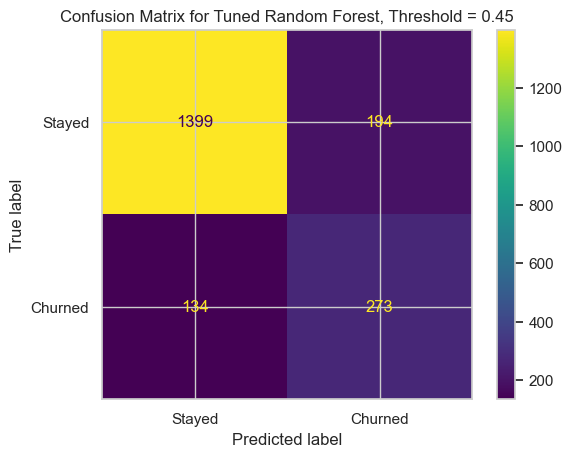

In [44]:
best_rf_pred_045 = (best_rf_proba >= 0.45).astype(int)
cm_tuned_045 = confusion_matrix(y_test, best_rf_pred_045)
print("Confusion matrix for tuned Random Forest, threshold 0.45:")
print(cm_tuned_045)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned_045,
    display_labels=["Stayed", "Churned"]
)
disp.plot()
plt.title("Confusion Matrix for Tuned Random Forest, Threshold = 0.45")
plt.savefig("fig_confusion_matrix_tuned_rf_threshold_045.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [46]:
hgb_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", HistGradientBoostingClassifier(
        random_state=42
    ))
])

In [47]:
hgb_cv = cross_validate(
    hgb_model,
    X,
    y,
    cv=cv,
    scoring=scoring_extended,
    n_jobs=-1
)

In [48]:
hgb_cv_results = pd.DataFrame([{
    "model": "HistGradientBoosting",
    "roc_auc_mean": hgb_cv["test_roc_auc"].mean(),
    "f1_mean": hgb_cv["test_f1"].mean(),
    "precision_mean": hgb_cv["test_precision"].mean(),
    "recall_mean": hgb_cv["test_recall"].mean()
}])

hgb_cv_results

,model,roc_auc_mean,f1_mean,precision_mean,recall_mean
0,HistGradientBoosting,0.862839,0.597579,0.745123,0.499286


In [49]:
hgb_model.fit(X_train, y_train)
hgb_proba = hgb_model.predict_proba(X_test)[:, 1]
hgb_pred_050 = hgb_model.predict(X_test)

In [50]:
print("HistGradientBoosting, threshold = 0.50")
print("ROC-AUC:", roc_auc_score(y_test, hgb_proba))
print("Precision:", precision_score(y_test, hgb_pred_050))
print("Recall:", recall_score(y_test, hgb_pred_050))
print("F1:", f1_score(y_test, hgb_pred_050))
print(classification_report(y_test, hgb_pred_050))

HistGradientBoosting, threshold = 0.50
ROC-AUC: 0.8574445015122981
Precision: 0.737037037037037
Recall: 0.48894348894348894
F1: 0.5878877400295421
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.74      0.49      0.59       407

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [51]:
hgb_thresholds = np.arange(0.10, 0.91, 0.05)
hgb_threshold_results = []
for threshold in hgb_thresholds:
    hgb_pred_threshold = (hgb_proba >= threshold).astype(int)

    hgb_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, hgb_pred_threshold),
        "recall": recall_score(y_test, hgb_pred_threshold),
        "f1": f1_score(y_test, hgb_pred_threshold)
    })

hgb_threshold_results = pd.DataFrame(hgb_threshold_results)
hgb_threshold_results

,threshold,precision,recall,f1
0,0.10,0.370021,0.867322,0.518736
1,0.15,0.437008,0.818182,0.569718
2,0.20,0.503236,0.764128,0.606829
3,0.25,0.550285,0.712531,0.620985
4,0.30,0.599109,0.660934,0.628505
5,0.35,0.634715,0.601966,0.617907
6,0.40,0.668588,0.570025,0.615385
7,0.45,0.712871,0.530713,0.608451
8,0.50,0.737037,0.488943,0.587888
9,0.55,0.790393,0.444717,0.569182


In [52]:
best_hgb_threshold_row = hgb_threshold_results.sort_values(
    "f1",
    ascending=False
).iloc[0]
best_hgb_threshold_row

threshold    0.300000
precision    0.599109
recall       0.660934
f1           0.628505
Name: 4, dtype: float64

In [53]:
best_hgb_threshold = best_hgb_threshold_row["threshold"]
hgb_pred_best = (hgb_proba >= best_hgb_threshold).astype(int)

final_model_comparison = pd.DataFrame([
    {
        "model": "Tuned Random Forest, threshold 0.45",
        "roc_auc": roc_auc_score(y_test, best_rf_proba),
        "precision": precision_score(y_test, best_rf_pred_045),
        "recall": recall_score(y_test, best_rf_pred_045),
        "f1": f1_score(y_test, best_rf_pred_045)
    },
    {
        "model": f"HistGradientBoosting, threshold {best_hgb_threshold:.2f}",
        "roc_auc": roc_auc_score(y_test, hgb_proba),
        "precision": precision_score(y_test, hgb_pred_best),
        "recall": recall_score(y_test, hgb_pred_best),
        "f1": f1_score(y_test, hgb_pred_best)
    }
])
final_model_comparison

,model,roc_auc,precision,recall,f1
0,"Tuned Random Forest, threshold 0.45",0.859470,0.584582,0.670762,0.624714
1,"HistGradientBoosting, threshold 0.30",0.857445,0.599109,0.660934,0.628505


In [54]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
tf.random.set_seed(42)

In [55]:
X_train_mlp = preprocess.fit_transform(X_train)
X_test_mlp = preprocess.transform(X_test)
if hasattr(X_train_mlp, "toarray"):
    X_train_mlp = X_train_mlp.toarray()

if hasattr(X_test_mlp, "toarray"):
    X_test_mlp = X_test_mlp.toarray()
print("Train shape:", X_train_mlp.shape)
print("Test shape:", X_test_mlp.shape)

Train shape: (8000, 13)
Test shape: (2000, 13)


In [57]:
classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights = {
    int(classes[i]): class_weights_array[i]
    for i in range(len(classes))
}
class_weights

{0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}

In [58]:
input_dim = X_train_mlp.shape[1]
mlp_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 192 (768.00 B)

In [59]:
mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

In [60]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=10,
    restore_best_weights=True
)

In [61]:
history = mlp_model.fit(
    X_train_mlp,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.6106 - loss: 0.7935 - precision: 0.2543 - recall: 0.6069 - val_auc: 0.7205 - val_loss: 0.7573 - val_precision: 0.2361 - val_recall: 0.9000
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - auc: 0.7227 - loss: 0.6511 - precision: 0.3333 - recall: 0.7061 - val_auc: 0.7716 - val_loss: 0.6326 - val_precision: 0.3513 - val_recall: 0.7531
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - auc: 0.7535 - loss: 0.6098 - precision: 0.3598 - recall: 0.7122 - val_auc: 0.8010 - val_loss: 0.5597 - val_precision: 0.4313 - val_recall: 0.6969
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - auc: 0.7794 - loss: 0.5736 - precision: 0.3894 - recall: 0.7160 - val_auc: 0.8212 - val_loss: 0.5106 - val_precision: 0.4886 - val_recall: 0.6687
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - auc: 0.7964 - loss: 0.5543 - precision: 0.4003 - recall: 0.7298 - val_auc: 0.8301 - val_loss: 0.4812 - val_precision: 0.4988 - val_recall: 0.6594
Epoch

In [62]:
mlp_proba = mlp_model.predict(X_test_mlp).ravel()
mlp_pred_050 = (mlp_proba >= 0.50).astype(int)
print("MLP, threshold = 0.50")
print("ROC-AUC:", roc_auc_score(y_test, mlp_proba))
print("Precision:", precision_score(y_test, mlp_pred_050))
print("Recall:", recall_score(y_test, mlp_pred_050))
print("F1:", f1_score(y_test, mlp_pred_050))
print(classification_report(y_test, mlp_pred_050))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step
MLP, threshold = 0.50
ROC-AUC: 0.8605261656109114
Precision: 0.49592169657422513
Recall: 0.7469287469287469
F1: 0.596078431372549
              precision    recall  f1-score   support

           0       0.93      0.81      0.86      1593
           1       0.50      0.75      0.60       407

    accuracy                           0.79      2000
   macro avg       0.71      0.78      0.73      2000
weighted avg       0.84      0.79      0.81      2000



In [63]:
mlp_thresholds = np.arange(0.10, 0.91, 0.05)
mlp_threshold_results = []
for threshold in mlp_thresholds:
    mlp_pred_threshold = (mlp_proba >= threshold).astype(int)
    mlp_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, mlp_pred_threshold),
        "recall": recall_score(y_test, mlp_pred_threshold),
        "f1": f1_score(y_test, mlp_pred_threshold)
    })

mlp_threshold_results = pd.DataFrame(mlp_threshold_results)
mlp_threshold_results

,threshold,precision,recall,f1
0,0.10,0.241965,0.980344,0.388132
1,0.15,0.270401,0.960688,0.422018
2,0.20,0.299922,0.941032,0.454869
3,0.25,0.329797,0.916462,0.485046
4,0.30,0.355446,0.882064,0.506704
5,0.35,0.384615,0.847666,0.529141
6,0.40,0.428753,0.828010,0.564962
7,0.45,0.456215,0.793612,0.579372
8,0.50,0.495922,0.746929,0.596078
9,0.55,0.540230,0.692875,0.607104


In [64]:
best_mlp_threshold_row = mlp_threshold_results.sort_values(
    "f1",
    ascending=False
).iloc[0]

best_mlp_threshold_row

threshold    0.650000
precision    0.644110
recall       0.631450
f1           0.637717
Name: 11, dtype: float64

In [65]:
best_mlp_threshold = best_mlp_threshold_row["threshold"]
mlp_pred_best = (mlp_proba >= best_mlp_threshold).astype(int)
final_model_comparison = pd.DataFrame([
    {
        "model": "Tuned Random Forest",
        "threshold": 0.45,
        "roc_auc": roc_auc_score(y_test, best_rf_proba),
        "precision": precision_score(y_test, best_rf_pred_045),
        "recall": recall_score(y_test, best_rf_pred_045),
        "f1": f1_score(y_test, best_rf_pred_045)
    },
    {
        "model": "HistGradientBoosting",
        "threshold": best_hgb_threshold,
        "roc_auc": roc_auc_score(y_test, hgb_proba),
        "precision": precision_score(y_test, hgb_pred_best),
        "recall": recall_score(y_test, hgb_pred_best),
        "f1": f1_score(y_test, hgb_pred_best)
    },
    {
        "model": "MLP Neural Network",
        "threshold": best_mlp_threshold,
        "roc_auc": roc_auc_score(y_test, mlp_proba),
        "precision": precision_score(y_test, mlp_pred_best),
        "recall": recall_score(y_test, mlp_pred_best),
        "f1": f1_score(y_test, mlp_pred_best)
    }
])
final_model_comparison

,model,threshold,roc_auc,precision,recall,f1
0,Tuned Random Forest,0.45,0.859470,0.584582,0.670762,0.624714
1,HistGradientBoosting,0.30,0.857445,0.599109,0.660934,0.628505
2,MLP Neural Network,0.65,0.860526,0.644110,0.631450,0.637717


In [66]:
background_sample = X_train_mlp[:200]
test_sample = X_test_mlp[:200]

In [67]:
mlp_explainer = shap.DeepExplainer(
    mlp_model,
    background_sample
)

/Users/german_hse/miniconda3/lib/python3.12/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/Users/german_hse/miniconda3/lib/python3.12/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 13))']
  warnings.warn(msg)


In [68]:
mlp_shap_values = mlp_explainer.shap_values(test_sample)

/Users/german_hse/miniconda3/lib/python3.12/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(400, 13))']
  warnings.warn(msg)


In [70]:
feature_names = preprocess.get_feature_names_out()
feature_names

array(['num__credit_score', 'num__age', 'num__tenure', 'num__balance',
       'num__products_number', 'num__credit_card', 'num__active_member',
       'num__estimated_salary', 'cat__country_France',
       'cat__country_Germany', 'cat__country_Spain', 'cat__gender_Female',
       'cat__gender_Male'], dtype=object)

In [71]:
print(type(mlp_shap_values))
print(np.array(mlp_shap_values).shape)

<class 'numpy.ndarray'>
(200, 13, 1)


In [72]:
mlp_shap_values_fixed = np.array(mlp_shap_values)
print("Original shape:", mlp_shap_values_fixed.shape)
if len(mlp_shap_values_fixed.shape) == 3 and mlp_shap_values_fixed.shape[2] == 1:
    mlp_shap_values_fixed = mlp_shap_values_fixed[:, :, 0]
print("Fixed shape:", mlp_shap_values_fixed.shape)

Original shape: (200, 13, 1)
Fixed shape: (200, 13)


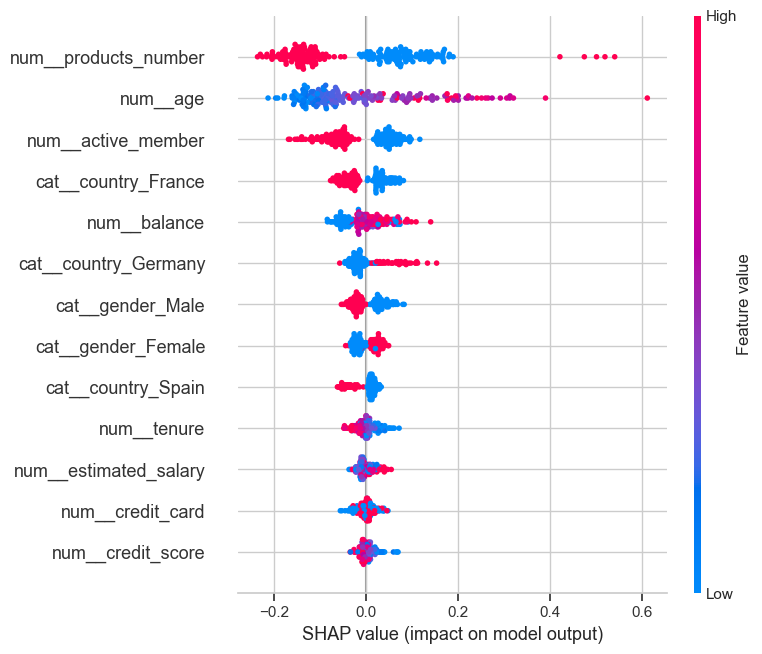

In [74]:
shap.summary_plot(
    mlp_shap_values_fixed,
    test_sample,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.savefig("fig_mlp_shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

In [75]:
mlp_shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(mlp_shap_values_fixed).mean(axis=0)
})
mlp_shap_importance = mlp_shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
)
mlp_shap_importance

,feature,mean_abs_shap
4,num__products_number,0.122394
1,num__age,0.109241
6,num__active_member,0.064709
8,cat__country_France,0.038456
3,num__balance,0.033958
9,cat__country_Germany,0.029277
12,cat__gender_Male,0.028277
11,cat__gender_Female,0.021051
10,cat__country_Spain,0.019541
2,num__tenure,0.015147


In [76]:
mlp_shap_importance.head(10)

,feature,mean_abs_shap
4,num__products_number,0.122394
1,num__age,0.109241
6,num__active_member,0.064709
8,cat__country_France,0.038456
3,num__balance,0.033958
9,cat__country_Germany,0.029277
12,cat__gender_Male,0.028277
11,cat__gender_Female,0.021051
10,cat__country_Spain,0.019541
2,num__tenure,0.015147


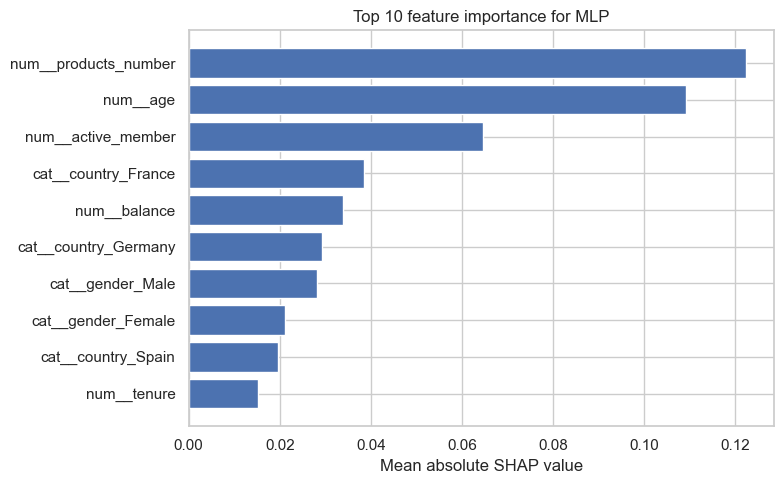

In [77]:
top_mlp_shap = mlp_shap_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(
    top_mlp_shap["feature"][::-1],
    top_mlp_shap["mean_abs_shap"][::-1]
)
plt.xlabel("Mean absolute SHAP value")
plt.title("Top 10 feature importance for MLP")
plt.tight_layout()
plt.savefig("fig_mlp_shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

In [78]:
sample_proba = mlp_model.predict(test_sample).ravel()
high_risk_idx = np.argmax(sample_proba)
print("Client index inside sample:", high_risk_idx)
print("Predicted churn probability:", sample_proba[high_risk_idx])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Client index inside sample: 49
Predicted churn probability: 0.9999686


In [79]:
single_client_shap = mlp_shap_values_fixed[high_risk_idx]
single_client_features = test_sample[high_risk_idx]

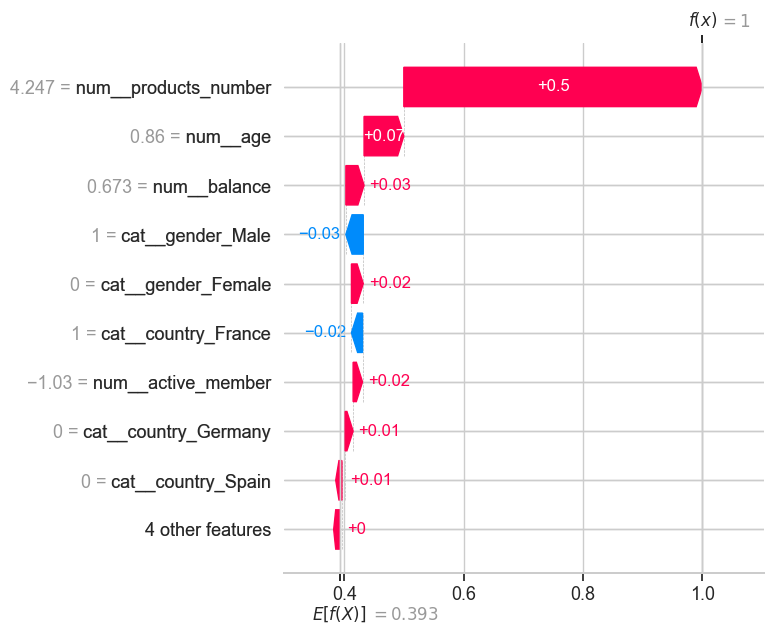

In [80]:
base_value = mlp_explainer.expected_value
if tf.is_tensor(base_value):
    base_value = base_value.numpy()

if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[0]

shap.plots.waterfall(
    shap.Explanation(
        values=single_client_shap,
        base_values=base_value,
        data=single_client_features,
        feature_names=feature_names
    ),
    show=False
)
plt.tight_layout()
plt.savefig("fig_local_waterfall.png", dpi=300, bbox_inches="tight")
plt.show()

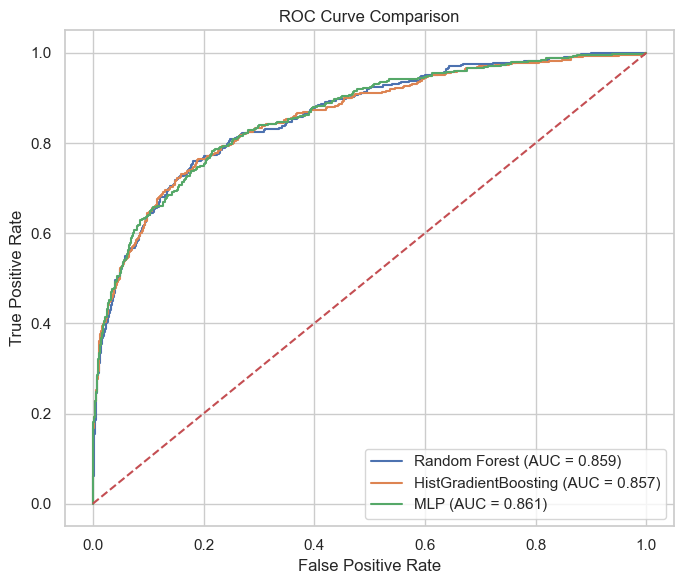

In [81]:
from sklearn.metrics import roc_curve, roc_auc_score
rf_fpr, rf_tpr, _ = roc_curve(y_test, best_rf_proba)
hgb_fpr, hgb_tpr, _ = roc_curve(y_test, hgb_proba)
mlp_fpr, mlp_tpr, _ = roc_curve(y_test, mlp_proba)

plt.figure(figsize=(7, 6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, best_rf_proba):.3f})"
)

plt.plot(
    hgb_fpr,
    hgb_tpr,
    label=f"HistGradientBoosting (AUC = {roc_auc_score(y_test, hgb_proba):.3f})"
)

plt.plot(
    mlp_fpr,
    mlp_tpr,
    label=f"MLP (AUC = {roc_auc_score(y_test, mlp_proba):.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("fig_final_roc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

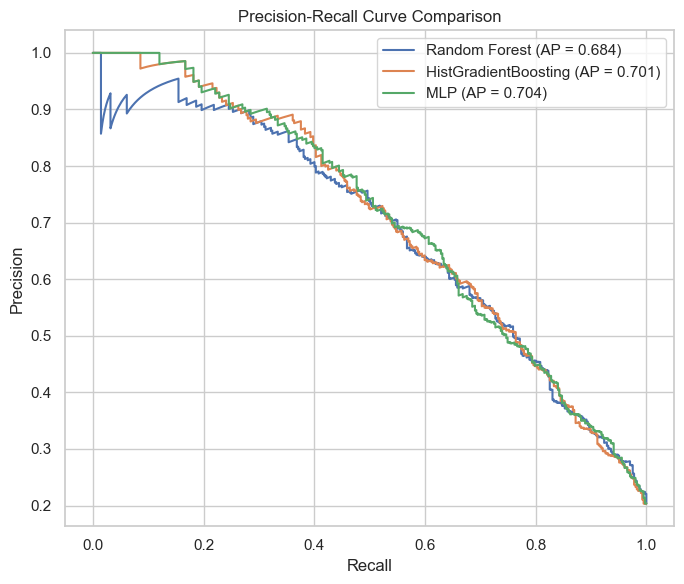

In [82]:
from sklearn.metrics import precision_recall_curve, average_precision_score
rf_precision_curve, rf_recall_curve, _ = precision_recall_curve(y_test, best_rf_proba)
hgb_precision_curve, hgb_recall_curve, _ = precision_recall_curve(y_test, hgb_proba)
mlp_precision_curve, mlp_recall_curve, _ = precision_recall_curve(y_test, mlp_proba)
plt.figure(figsize=(7, 6))
plt.plot(
    rf_recall_curve,
    rf_precision_curve,
    label=f"Random Forest (AP = {average_precision_score(y_test, best_rf_proba):.3f})"
)
plt.plot(
    hgb_recall_curve,
    hgb_precision_curve,
    label=f"HistGradientBoosting (AP = {average_precision_score(y_test, hgb_proba):.3f})"
)
plt.plot(
    mlp_recall_curve,
    mlp_precision_curve,
    label=f"MLP (AP = {average_precision_score(y_test, mlp_proba):.3f})"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("fig_final_pr_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

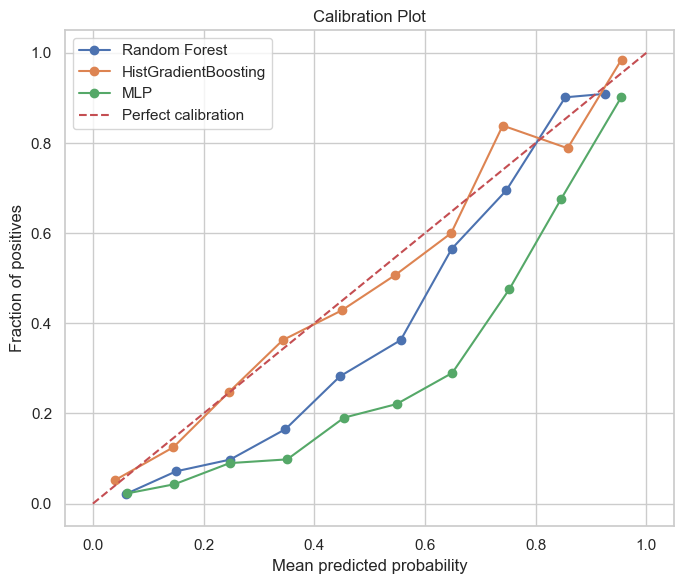

In [83]:
from sklearn.calibration import calibration_curve
rf_prob_true, rf_prob_pred = calibration_curve(
    y_test,
    best_rf_proba,
    n_bins=10,
    strategy="uniform"
)
hgb_prob_true, hgb_prob_pred = calibration_curve(
    y_test,
    hgb_proba,
    n_bins=10,
    strategy="uniform"
)
mlp_prob_true, mlp_prob_pred = calibration_curve(
    y_test,
    mlp_proba,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))
plt.plot(rf_prob_pred, rf_prob_true, marker="o", label="Random Forest")
plt.plot(hgb_prob_pred, hgb_prob_true, marker="o", label="HistGradientBoosting")
plt.plot(mlp_prob_pred, mlp_prob_true, marker="o", label="MLP")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Plot")
plt.legend()
plt.tight_layout()
plt.savefig("fig_final_calibration_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [84]:
df["balance_salary_ratio"] = (
    df["balance"] / (df["estimated_salary"] + 1)
)
df["products_per_tenure"] = (
    df["products_number"] / (df["tenure"] + 1)
)
df["engagement_score"] = (
    df["active_member"]
    + df["credit_card"]
    + df["products_number"]
)
df["age_balance_interaction"] = (
    df["age"] * df["balance"]
)

In [86]:
numerical_features = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary",
    "balance_salary_ratio",
    "products_per_tenure",
    "engagement_score",
    "age_balance_interaction"
]

In [87]:
X = df.drop(columns=["churn"])
y = df["churn"]

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [89]:
categorical_features = [
    "country",
    "gender"
]

In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
preprocess = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        numerical_features
    ),
    (
        "cat",
        OneHotEncoder(drop="first"),
        categorical_features
    )
])

In [92]:
X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

In [93]:
from sklearn.ensemble import HistGradientBoostingClassifier
hgb_new = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    random_state=42
)

hgb_new.fit(X_train_processed, y_train)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",6
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtyp

In [94]:
hgb_new_proba = hgb_new.predict_proba(X_test_processed)[:, 1]
print("HGB with engineered features")
print("ROC-AUC:", roc_auc_score(y_test, hgb_new_proba))

HGB with engineered features
ROC-AUC: 0.8411292648580785


In [95]:
classes = np.unique(y_train)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights = {
    int(classes[i]): class_weights_array[i]
    for i in range(len(classes))
}

In [96]:
tf.random.set_seed(42)
input_dim = X_train_processed.shape[1]
mlp_new = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

In [97]:
mlp_new.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(name="auc")
    ]
)

In [98]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=10,
    restore_best_weights=True
)

In [99]:
history = mlp_new.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=0
)

In [100]:
mlp_new_proba = mlp_new.predict(X_test_processed).ravel()
print("MLP with engineered features")
print("ROC-AUC:", roc_auc_score(y_test, mlp_new_proba))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 748us/step
MLP with engineered features
ROC-AUC: 0.8550677025253297


In [101]:
feature_engineering_comparison = pd.DataFrame([
    {
        "model": "Old HistGradientBoosting",
        "roc_auc": roc_auc_score(y_test, hgb_proba)
    },
    {
        "model": "New HistGradientBoosting",
        "roc_auc": roc_auc_score(y_test, hgb_new_proba)
    },
    {
        "model": "Old MLP",
        "roc_auc": roc_auc_score(y_test, mlp_proba)
    },
    {
        "model": "New MLP",
        "roc_auc": roc_auc_score(y_test, mlp_new_proba)
    }
])

feature_engineering_comparison

,model,roc_auc
0,Old HistGradientBoosting,0.857445
1,New HistGradientBoosting,0.841129
2,Old MLP,0.860526
3,New MLP,0.855068


In [106]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
y_test_array = np.array(y_test)
models_for_bootstrap = [
    {
        "model": "Tuned Random Forest",
        "proba": best_rf_proba,
        "threshold": 0.45
    },
    {
        "model": "HistGradientBoosting",
        "proba": hgb_proba,
        "threshold": 0.30
    },
    {
        "model": "MLP Neural Network",
        "proba": mlp_proba,
        "threshold": 0.70
    }
]
def bootstrap_metrics(y_true, y_proba, threshold, n_bootstrap=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    y_true = np.array(y_true)
    y_proba = np.array(y_proba)
    n = len(y_true)
    roc_auc_values = []
    precision_values = []
    recall_values = []
    f1_values = []
    for _ in range(n_bootstrap):
        sample_idx = rng.integers(0, n, n)
        y_true_sample = y_true[sample_idx]
        y_proba_sample = y_proba[sample_idx]
        if len(np.unique(y_true_sample)) == 2:
            roc_auc_values.append(
                roc_auc_score(y_true_sample, y_proba_sample)
            )
        y_pred_sample = (y_proba_sample >= threshold).astype(int)
        precision_values.append(
            precision_score(y_true_sample, y_pred_sample, zero_division=0)
        )
        recall_values.append(
            recall_score(y_true_sample, y_pred_sample, zero_division=0)
        )
        f1_values.append(
            f1_score(y_true_sample, y_pred_sample, zero_division=0)
        )
    def ci(values):
        return np.percentile(values, [2.5, 97.5])
    return {
        "roc_auc_ci": ci(roc_auc_values),
        "precision_ci": ci(precision_values),
        "recall_ci": ci(recall_values),
        "f1_ci": ci(f1_values)
    }

In [107]:
bootstrap_results = []
for model_info in models_for_bootstrap:
    model_name = model_info["model"]
    proba = model_info["proba"]
    threshold = model_info["threshold"]
    pred = (proba >= threshold).astype(int)
    point_roc_auc = roc_auc_score(y_test_array, proba)
    point_precision = precision_score(y_test_array, pred, zero_division=0)
    point_recall = recall_score(y_test_array, pred, zero_division=0)
    point_f1 = f1_score(y_test_array, pred, zero_division=0)

    ci_result = bootstrap_metrics(
        y_true=y_test_array,
        y_proba=proba,
        threshold=threshold,
        n_bootstrap=1000,
        random_state=42
    )

    bootstrap_results.append({
        "model": model_name,
        "threshold": threshold,
        "roc_auc": point_roc_auc,
        "roc_auc_95_ci": f"[{ci_result['roc_auc_ci'][0]:.3f}, {ci_result['roc_auc_ci'][1]:.3f}]",
        "precision": point_precision,
        "precision_95_ci": f"[{ci_result['precision_ci'][0]:.3f}, {ci_result['precision_ci'][1]:.3f}]",
        "recall": point_recall,
        "recall_95_ci": f"[{ci_result['recall_ci'][0]:.3f}, {ci_result['recall_ci'][1]:.3f}]",
        "f1": point_f1,
        "f1_95_ci": f"[{ci_result['f1_ci'][0]:.3f}, {ci_result['f1_ci'][1]:.3f}]"
    })

bootstrap_comparison = pd.DataFrame(bootstrap_results)
bootstrap_comparison.to_csv("bootstrap_model_comparison.csv", index=False)
bootstrap_comparison

,model,threshold,roc_auc,roc_auc_95_ci,precision,precision_95_ci,recall,recall_95_ci,f1,f1_95_ci
0,Tuned Random Forest,0.45,0.859470,"[0.836, 0.879]",0.584582,"[0.541, 0.630]",0.670762,"[0.622, 0.716]",0.624714,"[0.587, 0.663]"
1,HistGradientBoosting,0.30,0.857445,"[0.834, 0.879]",0.599109,"[0.556, 0.644]",0.660934,"[0.613, 0.706]",0.628505,"[0.591, 0.665]"
2,MLP Neural Network,0.70,0.860526,"[0.837, 0.880]",0.682857,"[0.634, 0.730]",0.587224,"[0.535, 0.634]",0.631440,"[0.587, 0.673]"
